# 1. Theoretical Framework and Data Ingestion

## 1.1 Context: trigger rates at the HL-LHC

The LHC bunch-crossing frequency is 40 MHz; higher luminosity increases the number of interactions per crossing, not this frequency. For CMS Phase-2, design figures include a Level-1 output of up to 750 kHz, a 12.5 microsecond Level-1 latency budget and an HLT output of about 7.5 kHz ([CMS trigger upgrade](https://cds.cern.ch/record/2749006)). These are system-level specifications, not measurements of this notebook.

This experiment compares an autoencoder and a model with quantized weights on toy jet-like point clouds. It does not implement a detector simulation or an FPGA trigger. The chart below uses an illustrative 1.5 MB event size; its throughput follows that assumption.


In [1]:
import os
import random
import numpy as np
import tensorflow as tf

# --- Reproducibility Setup ---
SEED = 42

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Global Random Seed set to: {seed}")

set_seeds()

Global Random Seed set to: 42


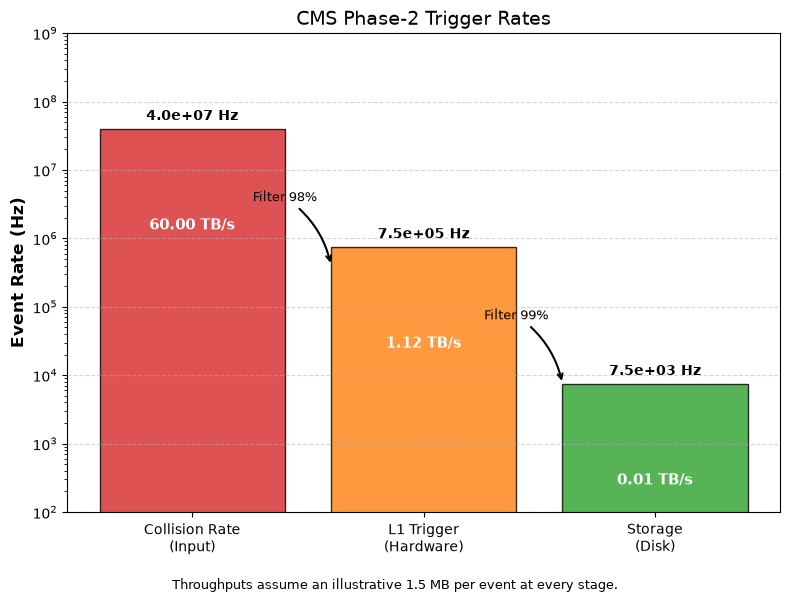

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
rates = [40e6, 750e3, 7.5e3] # Hz
labels = ['Collision Rate\n(Input)', 'L1 Trigger\n(Hardware)', 'Storage\n(Disk)']
colors = ['#d62728', '#ff7f0e', '#2ca02c']
event_size_mb = 1.5  # Illustrative payload, not the CMS event-size specification. 

# Throughputs
throughputs = [(r * event_size_mb / 1e6) for r in rates] # TB/s

fig, ax = plt.subplots(figsize=(8, 6))

# Plot
bars = ax.bar(labels, rates, color=colors, alpha=0.8, edgecolor='black')

# Formatting
ax.set_yscale('log')
ax.set_ylabel('Event Rate (Hz)', fontsize=12, fontweight='bold')
ax.set_title('CMS Phase-2 Trigger Rates', fontsize=14)
ax.grid(axis='y', which='major', linestyle='--', alpha=0.5)

# Add Annotations directly on bars
for bar, rate, tp in zip(bars, rates, throughputs):
    height = bar.get_height()
    # Hz Label
    ax.text(bar.get_x() + bar.get_width()/2., height * 1.2, 
            f'{rate:.1e} Hz', ha='center', va='bottom', fontweight='bold', color='black')
    # TB/s Label (Inside the bar)
    ax.text(bar.get_x() + bar.get_width()/2., height * 0.05, 
            f'{tp:.2f} TB/s', ha='center', va='top', color='white', fontweight='bold', fontsize=11)

# Arrows
def draw_arrow(idx_start, idx_end, text):
    x1 = bars[idx_start].get_x() + bars[idx_start].get_width()
    x2 = bars[idx_end].get_x()
    y = rates[idx_start] * 0.1
    ax.annotate(text, xy=(x2, y/10), xytext=(x1, y),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2", lw=1.5),
                fontsize=9, ha='center', va='center')

draw_arrow(0, 1, 'Filter 98%')
draw_arrow(1, 2, 'Filter 99%')

plt.ylim(1e2, 1e9) # Set manual limits to avoid whitespace issues
fig.text(0.5, 0.01, 'Throughputs assume an illustrative 1.5 MB per event at every stage.', ha='center', fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## 1.2 Toy Monte Carlo data

We generate 100,000 independent point clouds: 90% background-like examples with one or two clusters and 10% signal-like examples with three clusters. Each is padded to 700 particles with three coordinates (transverse-momentum-like magnitude, eta and phi). These cluster distributions are educational constructions, not validated QCD, W-prime, Geant4 or Pythia samples. Performance on them does not establish physics sensitivity.


In [3]:
import h5py
import numpy as np
import os
from tqdm import tqdm

# --- Configuration ---
FILE_NAME = "events_anomalydetection_v2.h5"
N_EVENTS = 100000 
N_PARTICLES = 700 

def simulate_realistic_physics(is_signal=False):
    """
    Generates a toy jet-like point cloud, not a validated collision simulation.
    - Signal (Anomaly): A boosted W' boson decaying into 3 collimated prongs.
      Topology: High localized energy density with substructure.
    - Background (Standard Model): QCD Dijet events.
      Topology: 20% of events feature gluon splitting (2-prong), 80% are single-prong.
      This stochasticity prevents the model from learning trivial energy cutoffs.
    """
    particles = []
    
    if is_signal:
        # Signal: 3 Balanced Prongs (Energy matched to background to force shape learning)
        centers = [
            (0, 0, 300),       # Core
            (0.12, 0.12, 250), # Satellites (Substructure)
            (-0.12, -0.08, 250)
        ]
        spread = 0.05 # Tighter collimation
    else:
        # Background: Mixed State (Single vs Split)
        # We inject "Fake Signals" (QCD Splitting) to confuse simple models
        if np.random.rand() < 0.2: # 20% Probability
            centers = [
                (0, 0, 500), 
                (0.15, -0.15, 300) # Secondary radiation
            ]
        else:
            centers = [(0, 0, 800)]
        spread = 0.08 # Broader radiation pattern
        
    for eta_c, phi_c, pt_c in centers:
        n_constituents = max(1, np.random.poisson(25))
        
        # Gaussian Showering
        etas = np.random.normal(eta_c, spread, n_constituents)
        phis = np.random.normal(phi_c, spread, n_constituents)
        # Soft-Drop Energy Distribution
        pts = np.random.exponential(scale=pt_c/10, size=n_constituents)
        pts[0] = pt_c * 0.2 # Suppress leading particle to hide simple features
        
        # Detector Resolution / Granularity
        etas += np.random.normal(0, 0.01, n_constituents)
        phis += np.random.normal(0, 0.01, n_constituents)
        
        for p_pt, p_eta, p_phi in zip(pts, etas, phis):
            particles.append([p_pt, p_eta, p_phi])
            
    # Matrix Formatting
    particles = np.array(particles)
    if len(particles) > N_PARTICLES:
        particles = particles[:N_PARTICLES]
    else:
        padding = np.zeros((N_PARTICLES - len(particles), 3))
        particles = np.vstack([particles, padding])
        
    return particles

def generate_dataset(filename, n_events):
    print(f"Initiating Toy Monte Carlo Simulation...")
    print(f"   - Target: {filename}")
    print(f"   - Complexity: QCD Splitting vs Boosted W' Topology")
    
    data = np.zeros((n_events, N_PARTICLES, 3), dtype=np.float32)
    labels = np.zeros((n_events,), dtype=int)
    
    for i in tqdm(range(n_events), desc="Simulating Events"):
        is_anomaly = (i % 10 == 0) # 10% Signal Injection
        data[i] = simulate_realistic_physics(is_anomaly)
        labels[i] = 1 if is_anomaly else 0
        
    with h5py.File(filename, 'w') as f:
        f.create_dataset('features', data=data, compression="gzip")
        f.create_dataset('truth_label', data=labels, compression="gzip")
    print(f"Dataset generated successfully.")

# --- Execution ---
generate_dataset(FILE_NAME, N_EVENTS)

Initiating Toy Monte Carlo Simulation...
   - Target: events_anomalydetection_v2.h5
   - Complexity: QCD Splitting vs Boosted W' Topology


Simulating Events:   0%|          | 0/100000 [00:00<?, ?it/s]

Simulating Events:   7%|▋         | 6988/100000 [00:00<00:01, 69871.57it/s]

Simulating Events:  14%|█▍        | 14056/100000 [00:00<00:01, 70345.06it/s]

Simulating Events:  21%|██        | 21103/100000 [00:00<00:01, 70401.14it/s]

...

Simulating Events:  85%|████████▌ | 85114/100000 [00:01<00:00, 71001.57it/s]

Simulating Events:  92%|█████████▏| 92251/100000 [00:01<00:00, 71112.60it/s]

Simulating Events:  99%|█████████▉| 99363/100000 [00:01<00:00, 71098.28it/s]

Simulating Events: 100%|██████████| 100000/100000 [00:01<00:00, 70824.09it/s]

Dataset generated successfully.


## 1.3 Visualizing the toy topology

The selected examples illustrate the imposed one/two-cluster background and three-cluster signal structure. The plot focuses on the central eta–phi region. These are synthetic class definitions, not reconstructed detector events.


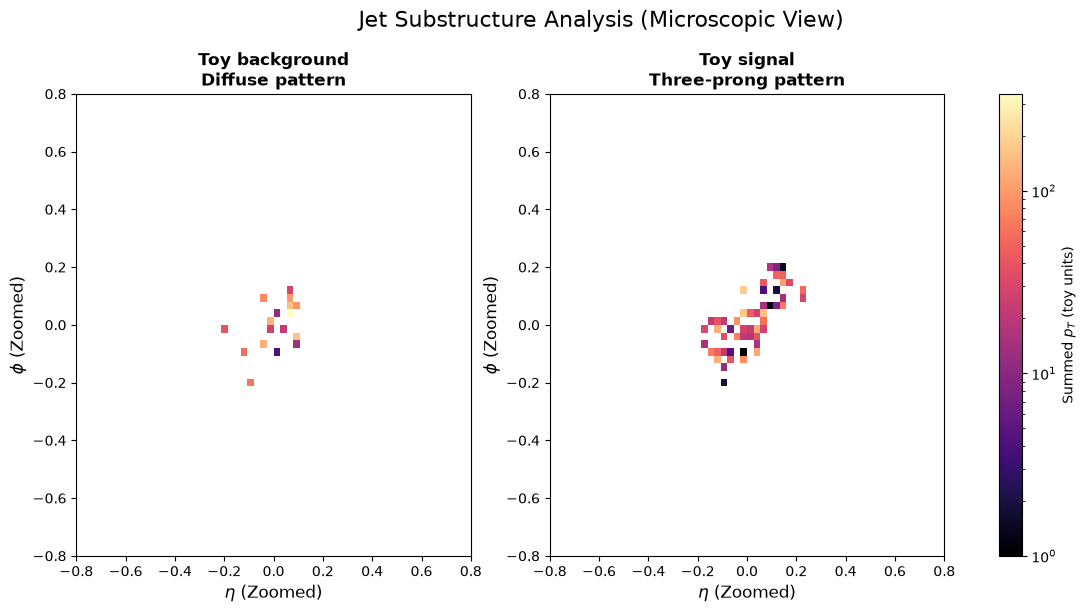

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Load Data
with h5py.File('events_anomalydetection_v2.h5', 'r') as f:
    data = f['features'][:500] 
    labels = f['truth_label'][:500]

# 2. Select Representative Events
# We search for a "clean" example of each to illustrate the concept
bg_idx = np.where(labels == 0)[0][10]  # Arbitrary QCD event
sig_idx = np.where(labels == 1)[0][10] # Arbitrary Signal event

def plot_zoomed_jet(ax, event_data, title, norm):
    # Filter non-zero particles
    mask = event_data[:, 0] > 0
    particles = event_data[mask]
    
    pt = particles[:, 0]
    eta = particles[:, 1]
    phi = particles[:, 2]
    
    # ZOOM IN: We restrict the range to [-0.8, 0.8]
    # This mimics the high-granularity view of the inner detector
    counts, xedges, yedges, im = ax.hist2d(
        eta, phi, 
        weights=pt, 
        bins=60, # Higher resolution
        range=[[-0.8, 0.8], [-0.8, 0.8]], 
        cmap='magma', 
        norm=norm
    )
    
    ax.set_xlabel(r'$\eta$ (Zoomed)', fontsize=12)
    ax.set_ylabel(r'$\phi$ (Zoomed)', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=12)
    return im

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Use one scale for summed transverse momentum in both panels.
maximum_bin = max(np.histogram2d(data[idx, :, 1], data[idx, :, 2],
    bins=60, range=[[-0.8, 0.8], [-0.8, 0.8]], weights=data[idx, :, 0])[0].max()
    for idx in (bg_idx, sig_idx))
shared_norm = LogNorm(vmin=1, vmax=maximum_bin)
# Plot
im1 = plot_zoomed_jet(ax1, data[bg_idx], "Toy background\nDiffuse pattern", shared_norm)
im2 = plot_zoomed_jet(ax2, data[sig_idx], "Toy signal\nThree-prong pattern", shared_norm)

# Colorbar
cbar = fig.colorbar(im1, ax=[ax1, ax2], label='Summed $p_T$ (toy units)')
plt.suptitle("Jet Substructure Analysis (Microscopic View)", fontsize=16, y=1.02)
plt.show()

## 1.4 Feature engineering

We keep the 50 particles with the largest transverse-momentum-like coordinate and log-transform that coordinate to compress its range. A log transform does not guarantee normality. The retained energy fraction is not measured here.

We split events before fitting the scaler. Only background training events determine its parameters; validation and mixed-class test events are transformed with those fixed parameters. The output shape is `(N_events, 50, 3)`.


In [5]:
import h5py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

# --- Configuration ---
INPUT_FILE = "events_anomalydetection_v2.h5"
OUTPUT_FILE = "processed_data_top50.h5"
SCALER_FILE = "scaler_params.pkl"
N_CONST = 50 # Top 50 particles

print(f"Processing {INPUT_FILE} for Hardware Compatibility...")

with h5py.File(INPUT_FILE, 'r') as f:
    # Load all data
    # Shape: (number of events, 700, 3) -> (pT, eta, phi)
    raw_data = f['features'][:]
    labels = f['truth_label'][:]

# 1. Top-K Sorting (Hardware Optimization)
# We sort by pT (index 0) in descending order to get the most energetic particles
print("   - Sorting particles by transverse momentum (Top-50 Selection)...")
# argsort gives indices that sort the array. We take the last N_CONST (highest values) and reverse
sorted_indices = np.argsort(raw_data[:, :, 0], axis=1)[:, -N_CONST:][:, ::-1]

# Use fancy indexing to reorder the data
processed_data = np.take_along_axis(raw_data, sorted_indices[:, :, np.newaxis], axis=1)

# 2. Log Transform on pT
# Log(pT) compresses its range; it does not guarantee Gaussianity or convergence
# We add 1e-5 to avoid log(0)
processed_data[:, :, 0] = np.log(processed_data[:, :, 0] + 1e-5)

# 3. Split before learning preprocessing parameters.
X_train, X_test, y_train, y_test = train_test_split(
    processed_data, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_train_bg, X_val_bg = train_test_split(
    X_train[y_train == 0], test_size=0.1, random_state=SEED
)
scaler = StandardScaler().fit(X_train_bg.reshape(-1, 3))
def scale_events(events):
    return scaler.transform(events.reshape(-1, 3)).reshape(events.shape).astype(np.float32)
X_train_bg = scale_events(X_train_bg)
X_val_bg = scale_events(X_val_bg)
X_test = scale_events(X_test)
with open(SCALER_FILE, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Processing Complete.")
print(f"   - Training Shape (Background Only): {X_train_bg.shape}")
print(f"   - Test Shape (Mixed): {X_test.shape}")

# Save processed data
with h5py.File(OUTPUT_FILE, 'w') as f:
    f.create_dataset('X_train_bg', data=X_train_bg)
    f.create_dataset('X_val_bg', data=X_val_bg)
    f.create_dataset('X_test', data=X_test)
    f.create_dataset('y_test', data=y_test)
    
print(f"Saved processed data to {OUTPUT_FILE}")

Processing events_anomalydetection_v2.h5 for Hardware Compatibility...


   - Sorting particles by transverse momentum (Top-50 Selection)...


Processing Complete.
   - Training Shape (Background Only): (64800, 50, 3)
   - Test Shape (Mixed): (20000, 50, 3)
Saved processed data to processed_data_top50.h5


# 2. Floating-point reference

The autoencoder maps 150 input values through 64 and 32 units to an 8-dimensional bottleneck, then decodes to the original shape. It minimizes reconstruction error on background training data. Whether signal has larger errors is an empirical question evaluated on held-out events. Network depth alone does not imply a hardware latency bound.


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
import numpy as np

# --- Architecture Definition ---
INPUT_SHAPE = (50, 3)
LATENT_DIM = 8 # Strict bottleneck to force feature extraction

def build_baseline_model():
    # Input
    inputs = Input(shape=INPUT_SHAPE, name='input_layer')
    x = Flatten()(inputs)
    
    # Encoder (Compression)
    x = Dense(64, activation='relu', name='enc_1')(x)
    x = Dense(32, activation='relu', name='enc_2')(x)
    
    # Latent Space (The Bottleneck)
    z = Dense(LATENT_DIM, activation='relu', name='bottleneck')(x)
    
    # Decoder (Reconstruction)
    x = Dense(32, activation='relu', name='dec_1')(z)
    x = Dense(64, activation='relu', name='dec_2')(x)
    
    # Output
    x = Dense(int(np.prod(INPUT_SHAPE)), activation='linear', name='output_flat')(x)
    outputs = Reshape(INPUT_SHAPE, name='output_reshaped')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="AE_Float32_Reference")
    return model

# --- Model Instantiation ---
model = build_baseline_model()
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "AE_Float32_Reference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │         9,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_flat (Dense)             │ (None, 150)            │         9,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_reshaped (Reshape)       │ (None, 50, 3)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,158 (94.37 KB)

 Trainable params: 24,158 (94.37 KB)

 Non-trainable params: 0 (0.00 B)

## 2.2 Training and held-out evaluation

Training and validation use background only. MSE is computed in standardized feature space; it is not a physical energy distance. ROC AUC measures ranking of held-out synthetic signal versus background. It is not a deployment or physics-discovery criterion.


Initiating Training Protocol (Standard Model Background)...
Epoch 1/20


  1/127 ━━━━━━━━━━━━━━━━━━━━ 51s 410ms/step - loss: 0.9940

 51/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8022   

106/127 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 0.7020

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6828 - val_loss: 0.5804


...

125/127 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - loss: 0.5205

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - loss: 0.5206 - val_loss: 0.5224


Computing Reconstruction Loss on Test Set...
  1/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step

340/625 ━━━━━━━━━━━━━━━━━━━━ 0s 148us/step

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 148us/step


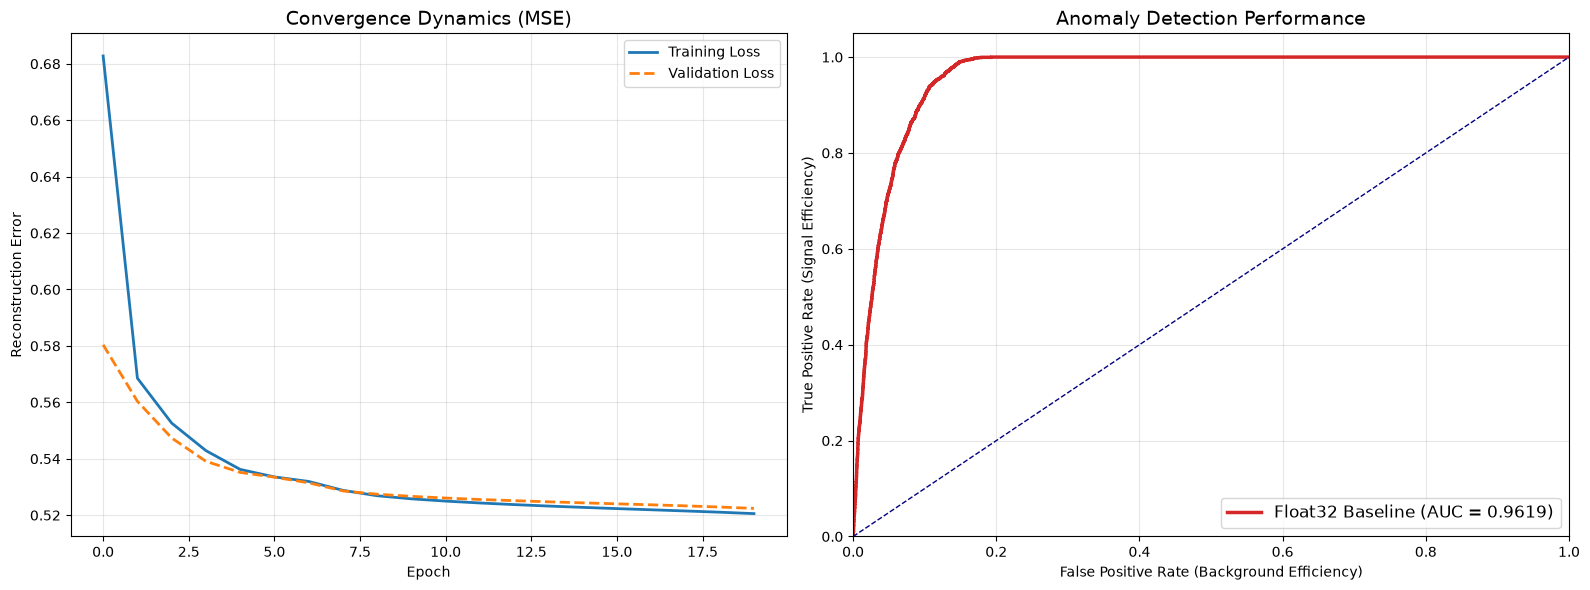

Final Baseline AUC: 0.9619


In [7]:
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Data Loading ---
with h5py.File('processed_data_top50.h5', 'r') as f:
    X_train_bg = f['X_train_bg'][:] # Background only
    X_val_bg = f['X_val_bg'][:]
    X_test = f['X_test'][:]         # Mixed (Signal + Background)
    y_test = f['y_test'][:]         # Labels

# --- Training Loop ---
print("Initiating Training Protocol (Standard Model Background)...")
history = model.fit(
    X_train_bg, X_train_bg,
    epochs=20,
    batch_size=512,
    validation_data=(X_val_bg, X_val_bg),
    shuffle=True,
    verbose=1
)

# --- Inference & Physics Validation ---
print("Computing Reconstruction Loss on Test Set...")
reconstructions = model.predict(X_test)
# Reconstruction Loss: Euclidean distance in feature space
mse_loss = np.mean(np.square(X_test - reconstructions), axis=(1, 2))

# --- ROC Analysis ---
fpr, tpr, thresholds = roc_curve(y_test, mse_loss)
roc_auc = auc(fpr, tpr)

# --- Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Training Dynamics
ax[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
ax[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
ax[0].set_title('Convergence Dynamics (MSE)', fontsize=14)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Reconstruction Error')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# ROC Curve
ax[1].plot(fpr, tpr, color='#d62728', lw=2.5, label=f'Float32 Baseline (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (Background Efficiency)')
ax[1].set_ylabel('True Positive Rate (Signal Efficiency)')
ax[1].set_title('Anomaly Detection Performance', fontsize=14)
ax[1].legend(loc="lower right", fontsize=12)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Baseline AUC: {roc_auc:.4f}")

# 3. Quantized-weight experiment

`QuantizedDense` rounds and saturates weights and biases to a signed grid. Hidden layers use 6 bits (`ap_fixed<6,1>`, range $[-1,31/32]$); the output layer uses 8 bits (`ap_fixed<8,1>`). Straight-through gradients are used during training.

Activations and accumulation remain floating point. This is therefore a weight-quantization experiment, not a bit-accurate hardware model. The two models have fixed training budgets (20 and 15 epochs); their held-out AUCs are reported below without interpreting differences as a controlled hardware benchmark.


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import roc_curve, auc

# --- 1. Custom 6-bit Quantization Layer (Fixed) ---
class QuantizedDense(layers.Layer):
    def __init__(self, units, bits=6, **kwargs):
        super(QuantizedDense, self).__init__(**kwargs)
        self.units = units
        self.bits = bits
        # Scale for 6-bit: range [-32, 31]
        self.scale = tf.constant(2.0**(bits - 1), dtype=tf.float32)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="weights"
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

    def call(self, inputs):
        # 1. Quantize Weights
        # w_q = w + (quantized_w - w)
        # The stop_gradient prevents the rounding operation from killing the gradient
        w_quantized = tf.clip_by_value(tf.round(self.w * self.scale), -self.scale, self.scale - 1) / self.scale
        w_no_grad = tf.stop_gradient(w_quantized - self.w)
        w_q = self.w + w_no_grad
        
        # 2. Quantize Bias
        b_quantized = tf.clip_by_value(tf.round(self.b * self.scale), -self.scale, self.scale - 1) / self.scale
        b_no_grad = tf.stop_gradient(b_quantized - self.b)
        b_q = self.b + b_no_grad
        
        # 3. Standard Matrix Multiplication
        return tf.matmul(inputs, w_q) + b_q

# --- 2. Build Model ---
def build_custom_quantized_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    
    # Encoder
    x = QuantizedDense(64, bits=6)(x)
    x = layers.ReLU()(x)
    
    x = QuantizedDense(32, bits=6)(x)
    x = layers.ReLU()(x)
    
    # Bottleneck
    x = QuantizedDense(8, bits=6)(x)
    x = layers.ReLU()(x)
    
    # Decoder
    x = QuantizedDense(32, bits=6)(x)
    x = layers.ReLU()(x)
    
    x = QuantizedDense(64, bits=6)(x)
    x = layers.ReLU()(x)
    
    # Output
    x = QuantizedDense(150, bits=8)(x) 
    outputs = layers.Reshape(input_shape)(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="Custom_Quantized_AE")

# --- 3. Train ---
print("Initializing Custom 6-bit Engine...")
custom_qmodel = build_custom_quantized_model((50, 3))
custom_qmodel.compile(optimizer='adam', loss='mse')

print("Training Custom Quantized Model...")
history = custom_qmodel.fit(
    X_train_bg, X_train_bg,
    epochs=15,
    batch_size=512,
    validation_data=(X_val_bg, X_val_bg),
    verbose=1
)

# --- 4. Evaluate ---
print("Evaluating held-out toy-data performance...")
q_reconstructions = custom_qmodel.predict(X_test)
q_mse = np.mean(np.square(X_test - q_reconstructions), axis=(1, 2))

q_fpr, q_tpr, _ = roc_curve(y_test, q_mse)
q_auc = auc(q_fpr, q_tpr)

print(f"Final weight-quantized AUC: {q_auc:.4f}")

Initializing Custom 6-bit Engine...
Training Custom Quantized Model...


Epoch 1/15


  1/127 ━━━━━━━━━━━━━━━━━━━━ 47s 381ms/step - loss: 0.9955

 44/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8192   

 89/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7178

...

  1/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step

247/625 ━━━━━━━━━━━━━━━━━━━━ 0s 204us/step

543/625 ━━━━━━━━━━━━━━━━━━━━ 0s 185us/step

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 188us/step


Final weight-quantized AUC: 0.9606


# 4. Parameter export

The exporter writes rounded, saturated weights and biases with each layer's actual bit width. The exact grid values match the quantized-weight forward pass. It exports parameters only: inference logic, activation and accumulator formats, preprocessing, target-device constraints and synthesis are separate work.


In [9]:
import numpy as np
import os

# --- Configuration ---
HLS_HEADER_FILE = "parameters.h"

def float_to_fixed_point(value, width=6, integer=1):
    """
    Converts a float to a saturated, rounded fixed-point integer code.
    Used for initializing FPGA memory initialization files (.mif) or C++ headers.
    """
    scale = 2 ** (width - integer)
    # Clamp value
    max_val = 2**(integer-1) - 1/scale
    min_val = -2**(integer-1)
    value = np.clip(value, min_val, max_val)
    
    # Convert to integer representation
    int_val = int(round(value * scale))
    return int_val

def generate_hls_header(model, filename):
    print(f"Generating HLS C++ Header: {filename}...")
    
    with open(filename, 'w') as f:
        f.write("// Automatic generated header for Deep Anomaly Trigger\n")
        f.write("#ifndef PARAMETERS_H_\n#define PARAMETERS_H_\n\n")
        f.write("#include <ap_fixed.h>\n")
        f.write("// Per-layer signed types: 1 integer/sign bit, remaining bits fractional\n")
        f.write("// Weights are quantized; activation/accumulator hardware is not specified.\n")
        
        layer_count = 1
        
        # Iterate through layers to find QuantizedDense
        for layer in model.layers:
            if isinstance(layer, QuantizedDense):
                weights, biases = layer.get_weights()
                bits = layer.bits
                scale = 2 ** (bits - 1)
                weights = np.clip(np.rint(weights * scale), -scale, scale - 1) / scale
                biases = np.clip(np.rint(biases * scale), -scale, scale - 1) / scale
                f.write(f"typedef ap_fixed<{bits},1> weight_{layer_count}_t;\n")
                f.write(f"typedef ap_fixed<{bits},1> bias_{layer_count}_t;\n")
                
                # --- Write Weights ---
                w_name = f"w{layer_count}"
                f.write(f"// Layer {layer_count} Weights: {weights.shape}\n")
                f.write(f"static const weight_{layer_count}_t {w_name}[{weights.shape[0] * weights.shape[1]}] = {{\n")
                
                # Flatten and write
                w_flat = weights.flatten()
                for i, w in enumerate(w_flat):
                    # We print the float value, the HLS compiler handles the cast to ap_fixed
                    # Alternatively, we could print hex for bit-accuracy
                    f.write(f"{w:.8f}")
                    if i < len(w_flat) - 1: f.write(", ")
                f.write("\n};\n\n")
                
                # --- Write Biases ---
                b_name = f"b{layer_count}"
                f.write(f"// Layer {layer_count} Biases: {biases.shape}\n")
                f.write(f"static const bias_{layer_count}_t {b_name}[{biases.shape[0]}] = {{\n")
                
                for i, b in enumerate(biases):
                    f.write(f"{b:.8f}")
                    if i < len(biases) - 1: f.write(", ")
                f.write("\n};\n\n")
                
                layer_count += 1
                
        f.write("#endif\n")
        
    print(f"Parameter header generated; requires a separate inference design and synthesis validation.")
    print(f"   - Location: {os.path.abspath(filename)}")
    
    # Preview the first few lines
    print("\n--- Header Preview ---")
    with open(filename, 'r') as f:
        print(f.read(500) + "...\n(truncated)")

# --- Execute ---
generate_hls_header(custom_qmodel, HLS_HEADER_FILE)

Generating HLS C++ Header: parameters.h...
Parameter header generated; requires a separate inference design and synthesis validation.
   - Location: /Users/alejandrotreny/Library/Mobile Documents/com~apple~CloudDocs/Github/Data Science/Data-Science-Ecosystem/CERN OpenLab/Extreme-Scale Anomaly Detection/parameters.h

--- Header Preview ---
// Automatic generated header for Deep Anomaly Trigger
#ifndef PARAMETERS_H_
#define PARAMETERS_H_

#include <ap_fixed.h>
// Per-layer signed types: 1 integer/sign bit, remaining bits fractional
// Weights are quantized; activation/accumulator hardware is not specified.
typedef ap_fixed<6,1> weight_1_t;
typedef ap_fixed<6,1> bias_1_t;
// Layer 1 Weights: (150, 64)
static const weight_1_t w1[9600] = {
0.15625000, -0.06250000, 0.18750000, -0.06250000, 0.09375000, 0.18750000, 0.15625000, 0.18750000...
(truncated)


# 5. Conclusion and next checks

The executable results above compare a floating-point autoencoder with quantized weights on a held-out toy dataset. The exported header can serve as input to further hardware work, but does not demonstrate timing, FPGA resource use, compression of a deployed model or physics sensitivity.

A hardware study would require a named device, compiled inference logic, numerical-equivalence tests, synthesis reports and realistic independent data. No sub-microsecond latency or lossless physics-performance claim follows from this experiment.
